In [97]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as imbpipeline

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.metrics import accuracy_score,f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

In [84]:
k=r"C:\Users\DELL\OneDrive\Desktop\test\titanic.csv"
df=pd.read_csv(k)

In [85]:
df.columns=df.columns.str.strip()

In [86]:
df=df.drop(columns=['Name','PassengerId','Cabin','Ticket'],axis=1)

In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    891 non-null    int64  
 1   Sex       891 non-null    object 
 2   Age       714 non-null    float64
 3   SibSp     891 non-null    int64  
 4   Parch     891 non-null    int64  
 5   Fare      891 non-null    float64
 6   Embarked  889 non-null    object 
 7   Survived  891 non-null    int64  
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [88]:
df[:2]

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
0,3,male,22.0,1,0,7.2500,S,0
1,1,female,38.0,1,0,71.2833,C,1


In [89]:
df.isnull().sum()

Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
Survived      0
dtype: int64

In [90]:
df.describe()

,Pclass,Age,SibSp,Parch,Fare,Survived
count,891.000000,714.000000,891.000000,891.000000,891.000000,891.000000
mean,2.308642,29.699118,0.523008,0.381594,32.204208,0.383838
std,0.836071,14.526497,1.102743,0.806057,49.693429,0.486592
min,1.000000,0.420000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,20.125000,0.000000,0.000000,7.910400,0.000000
50%,3.000000,28.000000,0.000000,0.000000,14.454200,0.000000
75%,3.000000,38.000000,1.000000,0.000000,31.000000,1.000000
max,3.000000,80.000000,8.000000,6.000000,512.329200,1.000000


In [96]:
df['Age'].median()

30.0

In [91]:
df['Age']=df['Age'].fillna(30)

In [101]:
df['Embarked']=df['Embarked'].fillna('Unknown')

C:\Users\DELL\AppData\Local\Temp\ipykernel_11896\1386553635.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Embarked']=df['Embarked'].fillna('Unknown')


In [93]:
df=df.dropna()

In [95]:
df.Pclass.value_counts()

Pclass
3    491
1    214
2    184
Name: count, dtype: int64

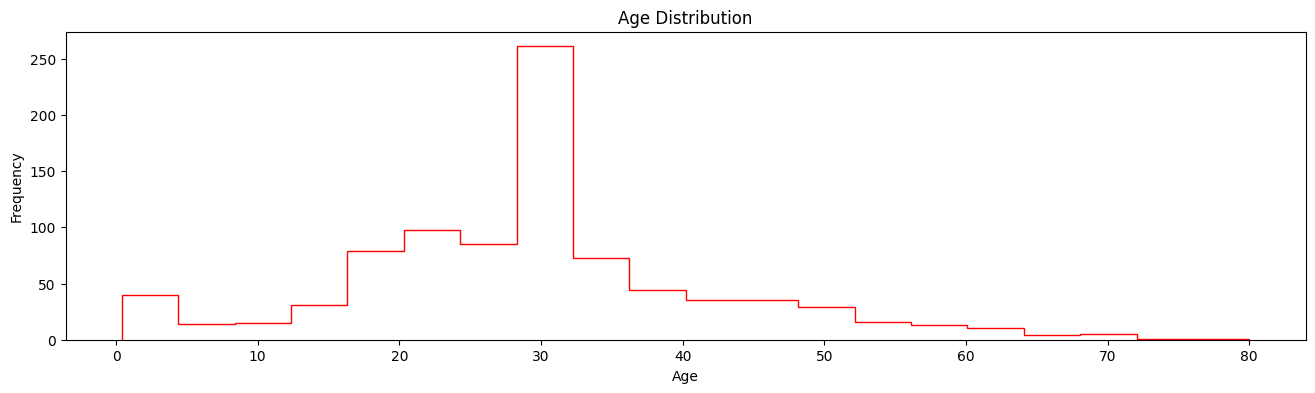

In [99]:
plt.figure(figsize=(16,4))
plt.hist(df.Age,bins=20,color='red',histtype='step')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')
plt.show()

In [102]:
print('Age Summary Statics:')
print(df.Age.describe())

Age Summary Statics:
count    889.000000
mean      29.713352
std       12.969135
min        0.420000
25%       22.000000
50%       30.000000
75%       35.000000
max       80.000000
Name: Age, dtype: float64


In [104]:
df['Age Category']=pd.cut(df.Age,bins=[0,15,30,60,81],labels=['Teens','Youths','Adults','Senior citizen'],include_lowest=True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_11896\3658064976.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Age Category']=pd.cut(df.Age,bins=[0,15,30,60,81],labels=['Teens','Youths','Adults','Senior citizen'],include_lowest=True)


In [105]:
df[:2]

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived,Age Category
0,3,male,22.0,1,0,7.2500,S,0,Youths
1,1,female,38.0,1,0,71.2833,C,1,Adults


In [106]:
df=df.drop('Age',axis=1)

In [107]:
df[:1]

,Pclass,Sex,SibSp,Parch,Fare,Embarked,Survived,Age Category
0,3,male,1,0,7.25,S,0,Youths


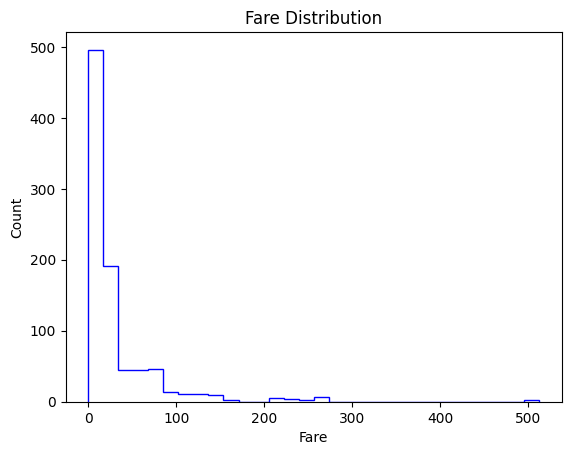

In [109]:
plt.Figure(figsize=(16,4))
plt.hist(df.Fare,bins=30,color='blue',histtype='step')
plt.xlabel('Fare')
plt.ylabel('Count')
plt.title('Fare Distribution')
plt.show()

In [ ]:
df["Fare Category"]=pd.cut(df.fare,bins=[])

In [ ]:
X=df.drop('Survived',axis=1)
y=df['Survived']

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
categorical_values=['Sex','Embarked']
numeric_values=['Pclass','Age','SibSp','Parch','Fare']

In [ ]:
process=ColumnTransformer(transformers=[
    ('cat',OneHotEncoder(handle_unknown='ignore'),categorical_values),
    ('num',StandardScaler(),numeric_values)
])

In [ ]:
models={
    'KNN':KNeighborsClassifier(n_neighbors=5),
    'LG':LogisticRegression(max_iter=1000)
}

In [ ]:
pipelines={}
for n,model in models.items():
    pipelines[n]=imbpipeline([
        ('pp',process),
        ('smt',SMOTE(random_state=42)),
        ('model',model)
    ])

In [ ]:
results=[]
for n,pipe in pipelines.items():
    pipe.fit(X_train,y_train)
    y_pred=pipe.predict(X_test)
    acc=accuracy_score(y_test,y_pred)
    f1=f1_score(y_test,y_pred)
    print(f"{n}->Accuracy:{acc},F1:{f1}")

KNN->Accuracy:0.7988826815642458,F1:0.7567567567567568
LG->Accuracy:0.8100558659217877,F1:0.7605633802816901
